# 2. 서울시 119 이송 건수·인구 밀집 — 예측

`1_119_전처리.ipynb`가 만든 `ml_data`의 csv로 모델을 학습하고 예측합니다.

**흐름**
- A. 이송 건수 (자치구 × 월) : 모델 6종 비교 → 최고 모델 저장 → 구별 미래 6개월 예측
- B. 인구 밀집 (자치구 × 일) : 모델 6종 비교 → 최고 모델 저장 → 평가 기간 예측

**공통 기준**
- 모델 6종 : LinearRegression · Ridge · DecisionTree · RandomForest · GradientBoosting · DNN(Keras)
- 정확도 : (1 − MAPE) × 100, 실제값 대비 평균 오차 비율을 뺀 값
- 분할 : 시간순 (과거로 학습, 최근으로 평가)
- 결과 csv : 모두 `지역구명` 컬럼 포함

## 0. 환경 설정
- 머신러닝 모델 저장 : pickle (9장 파일 입출력)
- 딥러닝 모델 저장·불러오기 : h5, `save_model()` / `load_model()` (1장·6장)
- DNN 과적합 방지 : Dense → BatchNormalization → Dropout, L2 규제, he_normal 초기화 (6장·8장)
- 콜백 : EarlyStopping(개선 없으면 중단) · ReduceLROnPlateau(정체 시 학습률 0.5배) (7장·8장)

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 한글 폰트 자동 선택
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    print('[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

TEST_MONTHS = 6        # 이송 건수 : 최근 6개월로 평가
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GU_LIST = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
           '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
           '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
MODEL_NAMES = ['LinearRegression', 'Ridge', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'DNN']

## 0-1. 공통 함수
- `make_ml_models` : 주제별 머신러닝 5종 (데이터 크기에 맞춘 설정)
- `build_dnn` : 강의자료 방식 DNN, 출력층은 회귀라서 활성화 함수 없는 `Dense(1)`
- `fit_model` : 스케일러 + 모델을 한 묶음(dict)으로 학습
  - `StandardScaler` : 학습 데이터에만 fit (평가 데이터 정보 누출 방지)
  - DNN 타겟도 스케일 조정 : 큰 숫자를 작게 만들어 학습 안정화 → `inverse_transform`으로 원래 단위 복원
- `evaluate` : 정확도(%) · R2 · MAE · RMSE

In [2]:
DNN_SETTINGS = {
    'transport':  {'units': [64, 32],      'epochs': 500, 'batch_size': 32,  'patience': 30},
    'population': {'units': [128, 64, 32], 'epochs': 100, 'batch_size': 256, 'patience': 10},
}


def make_ml_models(topic):
    if topic == 'transport':
        return {
            'LinearRegression': LinearRegression(),
            'Ridge': Ridge(alpha=1.0),
            'DecisionTree': DecisionTreeRegressor(max_depth=6, random_state=SEED),
            'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=10, n_jobs=-1, random_state=SEED),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                          random_state=SEED),
        }
    return {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=SEED),
        'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=SEED),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=SEED),
    }


def build_dnn(n_features, units):
    model = Sequential([Input(shape=(n_features,))])
    for u in units:
        model.add(Dense(u, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model


def fit_model(name, X, y, topic):
    x_scaler = StandardScaler().fit(X)
    Xs = x_scaler.transform(X)
    bundle = {'name': name, 'x_scaler': x_scaler, 'y_scaler': None, 'history': None, 'columns': list(X.columns)}

    if name == 'DNN':
        s = DNN_SETTINGS[topic]
        y_scaler = StandardScaler().fit(y.values.reshape(-1, 1))
        model = build_dnn(Xs.shape[1], s['units'])
        early_stop = EarlyStopping(monitor='val_loss', patience=s['patience'], restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=s['patience'] // 2, min_lr=1e-6)
        hist = model.fit(Xs, y_scaler.transform(y.values.reshape(-1, 1)),
                         epochs=s['epochs'], batch_size=s['batch_size'], validation_split=0.2,
                         callbacks=[early_stop, reduce_lr], verbose=0)
        bundle.update({'y_scaler': y_scaler, 'history': hist.history})
    else:
        model = make_ml_models(topic)[name]
        model.fit(Xs, y)

    bundle['model'] = model
    return bundle


def predict(bundle, X):
    Xs = bundle['x_scaler'].transform(X)
    if bundle['name'] == 'DNN':
        pred = bundle['model'].predict(Xs, verbose=0)
        return bundle['y_scaler'].inverse_transform(pred).flatten()
    return bundle['model'].predict(Xs)


def evaluate(y_true, y_pred):
    return {
        '정확도(%)': (1 - mean_absolute_percentage_error(y_true, y_pred)) * 100,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def plot_history(history, title, save_path):
    # 학습 곡선 : val_loss가 다시 오르면 과적합 신호
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], 'y', label='train_loss')
    plt.plot(history['val_loss'], 'r', label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def save_bundle(bundle, prefix):
    # 머신러닝 : 묶음 전체를 pickle / DNN : 모델은 h5, 나머지(스케일러 등)는 pickle
    if bundle['name'] == 'DNN':
        save_model(bundle['model'], RESULT_DIR / f'{prefix}_best_model.h5')
        rest = {k: v for k, v in bundle.items() if k != 'model'}
        with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
            pickle.dump(rest, f)
    else:
        with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
            pickle.dump(bundle, f)


def load_bundle(prefix):
    with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'rb') as f:
        bundle = pickle.load(f)
    if bundle['name'] == 'DNN':
        bundle['model'] = load_model(RESULT_DIR / f'{prefix}_best_model.h5')
    return bundle

---
# A. 이송 건수 예측 (자치구 × 월)

## A-1. 데이터 불러오기
- `transport_dataset` : 학습 데이터 전체
- `features_transport` : 전처리에서 `선택`된 특성 목록
- `transport_future` : 미래 예측용 입력 행 (정답 없음)
- 빈 값이 있는 행 제거 : 빈 값을 임의 값으로 채우지 않음

In [3]:
target = 'transport_cnt'

full = pd.read_csv(ML_DATA_DIR / 'transport_dataset.csv', encoding='utf-8-sig', parse_dates=['ds'])
feat_info = pd.read_csv(ML_DATA_DIR / 'features_transport.csv', encoding='utf-8-sig')
future = pd.read_csv(ML_DATA_DIR / 'transport_future.csv', encoding='utf-8-sig', parse_dates=['ds'])

num_features = feat_info.loc[feat_info['결과'] == '선택', '컬럼'].tolist()
data = full.dropna(subset=num_features + [target]).sort_values(['ds', 'District']).reset_index(drop=True)

print('선택 특성 :', num_features)
print(f'전체 {len(full)}행 -> 학습 가능 {len(data)}행')
print('기간 :', data['ds'].min().date(), '~', data['ds'].max().date())

선택 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전년동월_y', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']
전체 2548행 -> 학습 가능 2132행
기간 : 2018-05-01 ~ 2025-12-01


## A-2. 모델 입력 만들기 · 시간순 분할
- 숫자 특성 : 전처리에서 선택된 컬럼
- `구_OO구` 원-핫 : 구마다 다른 기본 이송 규모
- `월_1 ~ 월_12` 원-핫 : 계절 효과 (전처리 3-1 시계열 분해에서 확인)
- 카테고리 고정 : 학습·평가·미래 예측의 입력 컬럼이 항상 같게
- 평가 기간 : 마지막 `TEST_MONTHS`개월

In [4]:
def make_X(df):
    df = df.reset_index(drop=True)
    gu_dummy = pd.get_dummies(pd.Categorical(df['District'], categories=GU_LIST), prefix='구', dtype=int)
    month_dummy = pd.get_dummies(pd.Categorical(df['월'], categories=range(1, 13)), prefix='월', dtype=int)
    return pd.concat([df[num_features], gu_dummy, month_dummy], axis=1)


test_start = sorted(data['ds'].unique())[-TEST_MONTHS]
train = data[data['ds'] < test_start].reset_index(drop=True)
test = data[data['ds'] >= test_start].reset_index(drop=True)

X_train, y_train = make_X(train), train[target]
X_test, y_test = make_X(test), test[target]

print('입력 컬럼 수 :', X_train.shape[1])
print(f'학습 : {len(train)}행 ({train["ds"].min():%Y-%m} ~ {train["ds"].max():%Y-%m})')
print(f'평가 : {len(test)}행 ({test["ds"].min():%Y-%m} ~ {test["ds"].max():%Y-%m})')

입력 컬럼 수 : 46
학습 : 1982행 (2018-05 ~ 2025-06)
평가 : 150행 (2025-07 ~ 2025-12)


## A-3. 평가 방법 두 가지
- **1개월 예측** : 실제 지난달 값을 알고 다음 달 한 달만 예측
- **6개월 연속 예측** : 평가 시작 전 달까지만 알고 6개월을 차례로 예측 (A-7 미래 예측과 같은 방식)
  - 재귀 예측 : 이번 달 예측값 → 다음 달의 `전월_transport_cnt`로 사용
- 최고 모델 선택 기준 : 6개월 연속 예측 정확도 (실제로 쓰는 방식)
- 기준선 2종 (모델이 이보다 나아야 의미 있음)
  - 마지막 달 유지 : 1개월은 "지난달 그대로", 6개월은 "평가 직전 달 값 유지"
  - 전년 동월 : 작년 같은 달 값 그대로

In [5]:
def predict_months(bundle, rows):
    # 한 달씩 예측하고, 예측값을 다음 달 '전월_transport_cnt'로 넣기
    rows = rows.sort_values(['ds', 'District']).reset_index(drop=True)
    parts = []
    prev = None
    for m in sorted(rows['ds'].unique()):
        part = rows[rows['ds'] == m].copy()
        if prev is not None:
            part['전월_transport_cnt'] = part['District'].map(prev).fillna(part['전월_transport_cnt'])
        part = part.dropna(subset=num_features)
        part['예측'] = predict(bundle, make_X(part))
        prev = part.set_index('District')['예측']
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


scores = []
bundles = {}
rec_preds = {}
for name in MODEL_NAMES:
    bundle = fit_model(name, X_train, y_train, 'transport')
    bundles[name] = bundle

    one = evaluate(y_test, predict(bundle, X_test))
    rec = predict_months(bundle, test)
    rec_preds[name] = rec
    six = evaluate(rec[target], rec['예측'])

    scores.append({'모델': name, '6개월_정확도(%)': six['정확도(%)'], '6개월_MAE': six['MAE'],
                   '1개월_정확도(%)': one['정확도(%)'], '1개월_R2': one['R2']})
    print(f'{name:18s} 완료')

# 기준선 1 : 마지막 달 유지
last_value = full[full['ds'] < test_start].sort_values('ds').groupby('District')[target].last()
naive_six = evaluate(y_test, test['District'].map(last_value))
naive_one = evaluate(y_test, test['전월_transport_cnt'])
scores.append({'모델': '기준선(마지막 달 유지)', '6개월_정확도(%)': naive_six['정확도(%)'], '6개월_MAE': naive_six['MAE'],
               '1개월_정확도(%)': naive_one['정확도(%)'], '1개월_R2': naive_one['R2']})

# 기준선 2 : 전년 동월
ok = test['전년동월_transport_cnt'].notna()
season = evaluate(y_test[ok], test.loc[ok, '전년동월_transport_cnt'])
scores.append({'모델': '기준선(전년 동월)', '6개월_정확도(%)': season['정확도(%)'], '6개월_MAE': season['MAE'],
               '1개월_정확도(%)': season['정확도(%)'], '1개월_R2': season['R2']})

score_df = pd.DataFrame(scores).sort_values('6개월_정확도(%)', ascending=False).reset_index(drop=True)
score_df.to_csv(RESULT_DIR / 'transport_model_scores.csv', index=False, encoding='utf-8-sig')
print(score_df.round(3).to_string(index=False))

best_name = score_df[score_df['모델'].isin(MODEL_NAMES)].iloc[0]['모델']
best_rec = rec_preds[best_name]
print('\n최고 모델 (6개월 연속 예측 기준) :', best_name)

LinearRegression   완료
Ridge              완료
DecisionTree       완료
RandomForest       완료
GradientBoosting   완료
DNN                완료
              모델  6개월_정확도(%)  6개월_MAE  1개월_정확도(%)  1개월_R2
GradientBoosting      94.038   57.212      95.032   0.931
           Ridge      93.893   57.522      94.727   0.929
LinearRegression      93.880   57.674      94.724   0.929
    RandomForest      93.571   61.064      95.332   0.937
   기준선(마지막 달 유지)      93.252   66.353      95.409   0.932
      기준선(전년 동월)      90.680   90.853      90.680   0.775
    DecisionTree      90.114   94.074      94.377   0.918
             DNN      88.398  105.122      93.985   0.904

최고 모델 (6개월 연속 예측 기준) : GradientBoosting


## A-4. 시각화 ① 모델 비교 · DNN 학습 곡선
- 막대 색 : 빨강 = 최고 모델, 회색 = 기준선
- 학습 곡선 : train_loss와 val_loss 간격이 벌어지면 과적합

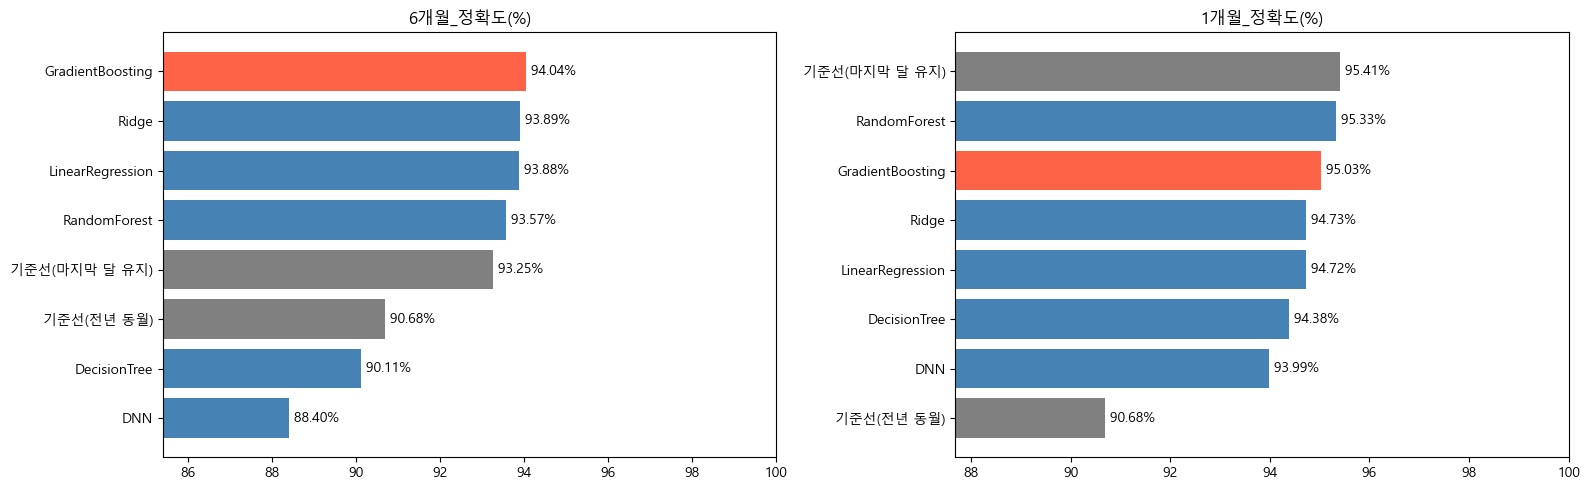

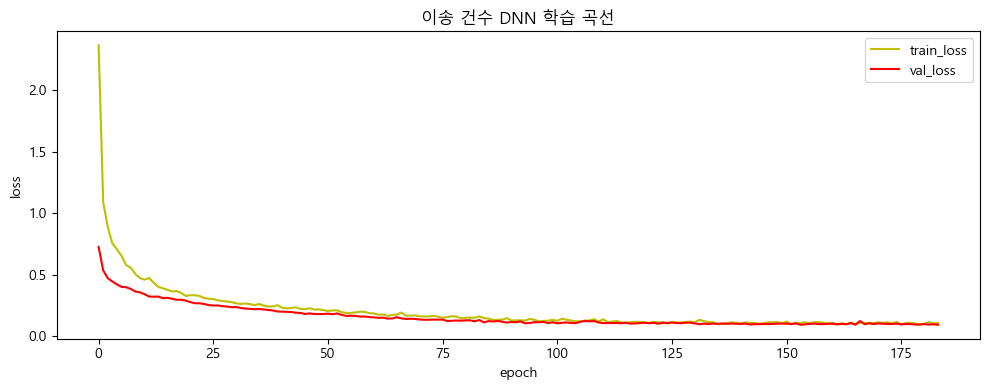

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, ['6개월_정확도(%)', '1개월_정확도(%)']):
    plot_df = score_df.sort_values(col)
    colors = ['gray' if m.startswith('기준선') else ('tomato' if m == best_name else 'steelblue')
              for m in plot_df['모델']]
    ax.barh(plot_df['모델'], plot_df[col], color=colors)
    for i, v in enumerate(plot_df[col]):
        ax.text(v, i, f' {v:.2f}%', va='center')
    ax.set_xlim(plot_df[col].min() - 3, 100)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_model_scores.png')
plt.show()

plot_history(bundles['DNN']['history'], '이송 건수 DNN 학습 곡선', RESULT_DIR / 'transport_dnn_history.png')

## A-5. 시각화 ② 평가 기간 결과
- 산점도 : 대각선(y=x)에 가까울수록 정확
- 구별 평균 오차율 : 오차율 = |예측 − 실제| / 실제 × 100
- 상위 4개 구 추이 : 실선 = 실제, 빨간 점선 = 6개월 연속 예측
- 결과 csv : `transport_test_predictions.csv` (지역구명 포함)

**구로구의 경우, 소방서의 신설, 병합이 이루어져 예측값 계산에 혼선 발생**

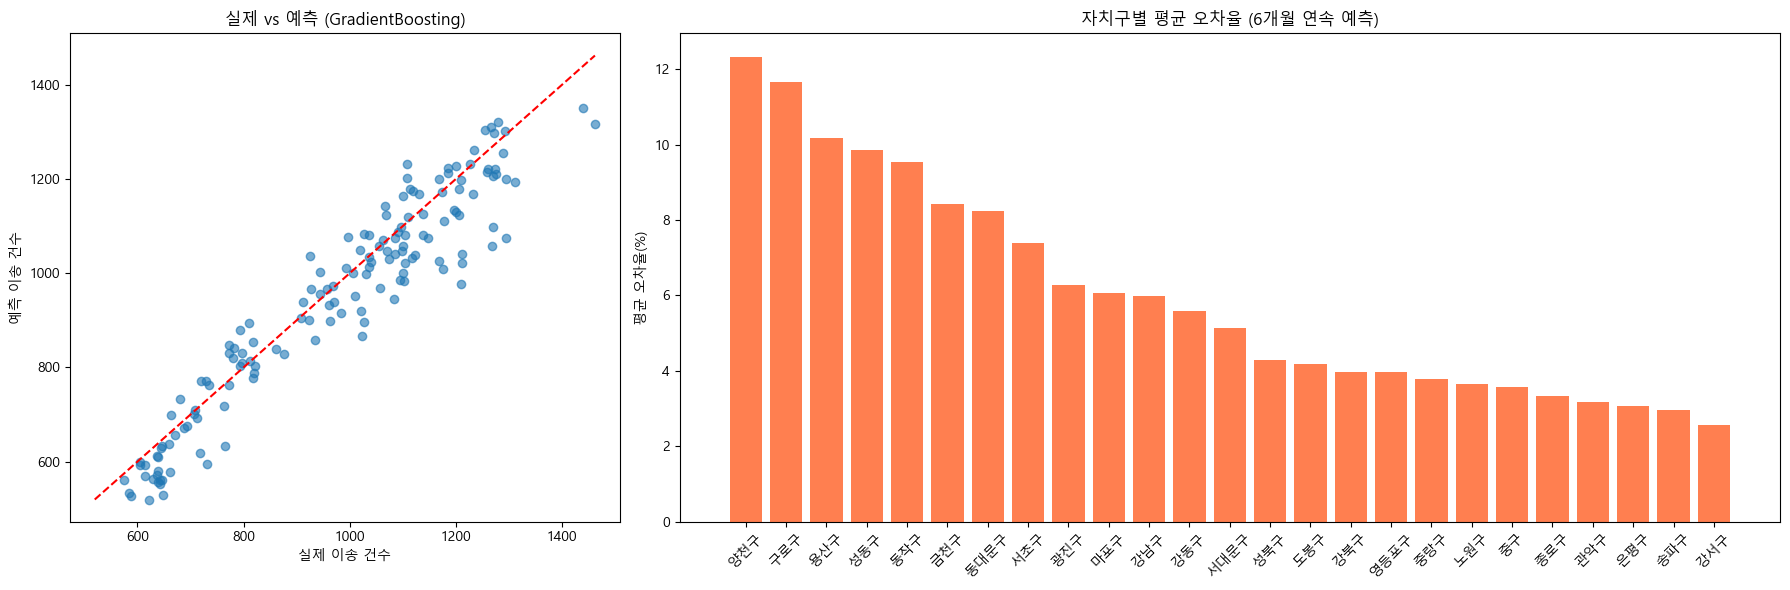

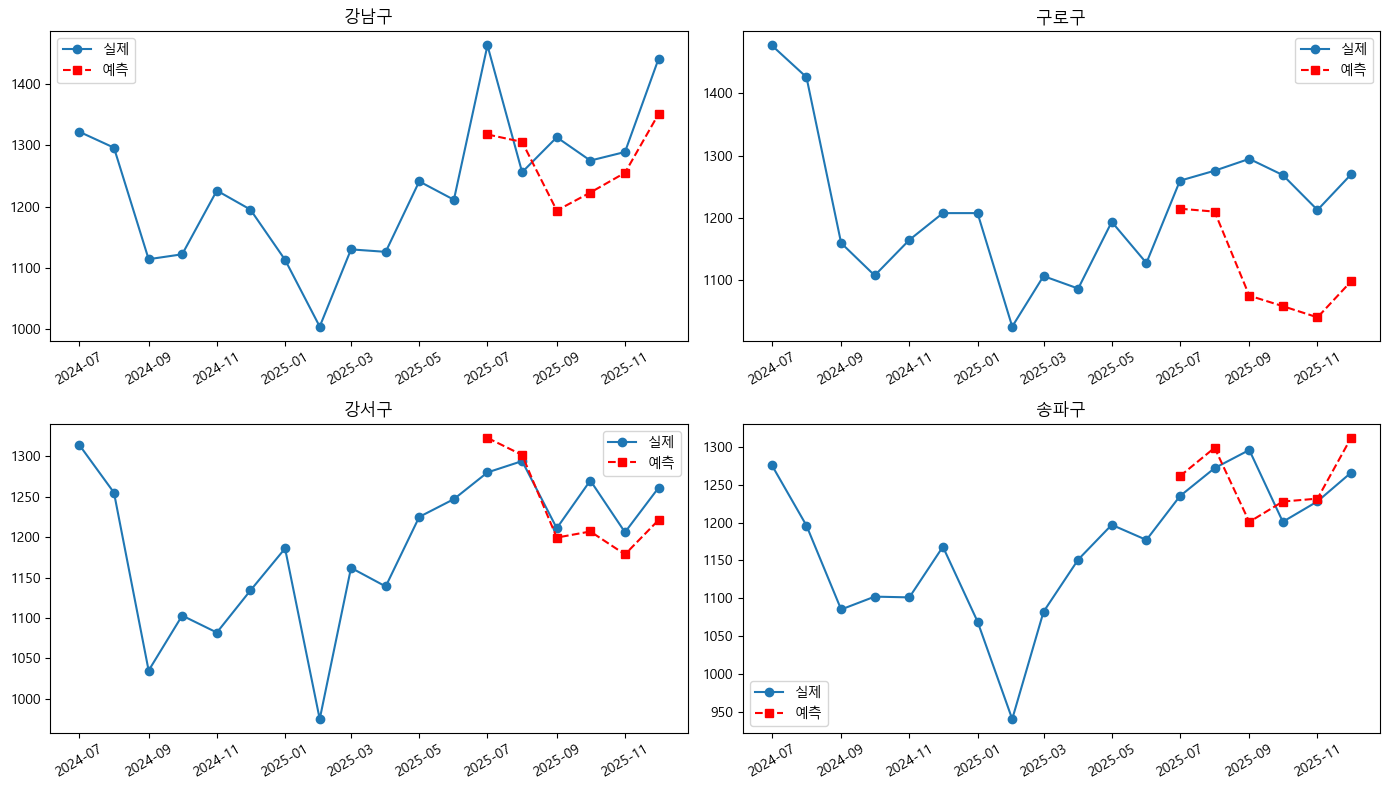

In [7]:
test_result = pd.DataFrame({
    '날짜': best_rec['ds'].dt.strftime('%Y-%m'),
    '지역구명': best_rec['District'],
    '실제_이송건수': best_rec[target].values,
    '예측_이송건수': best_rec['예측'].round(0),
})
test_result['오차율(%)'] = ((test_result['예측_이송건수'] - test_result['실제_이송건수']).abs()
                          / test_result['실제_이송건수'] * 100).round(2)
test_result.to_csv(RESULT_DIR / 'transport_test_predictions.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2]})
axes[0].scatter(best_rec[target], best_rec['예측'], alpha=0.6)
lim = [best_rec[[target, '예측']].min().min(), best_rec[[target, '예측']].max().max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('실제 이송 건수')
axes[0].set_ylabel('예측 이송 건수')
axes[0].set_title(f'실제 vs 예측 ({best_name})')

gu_err = test_result.groupby('지역구명')['오차율(%)'].mean().sort_values(ascending=False)
axes[1].bar(gu_err.index, gu_err.values, color='coral')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('평균 오차율(%)')
axes[1].set_title('자치구별 평균 오차율 (6개월 연속 예측)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_test_result.png')
plt.show()

top4 = test_result.groupby('지역구명')['실제_이송건수'].sum().sort_values(ascending=False).head(4).index
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, gu in zip(axes.flatten(), top4):
    real = full[(full['District'] == gu) & (full['ds'] >= test_start - pd.DateOffset(months=12))]
    pred = best_rec[best_rec['District'] == gu]
    ax.plot(real['ds'], real[target], marker='o', label='실제')
    ax.plot(pred['ds'], pred['예측'], 'r--', marker='s', label='예측')
    ax.set_title(gu)
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_test_trend.png')
plt.show()

## A-6. 특성 중요도
- 목적 : 상관계수가 놓친 곡선 관계·여러 컬럼의 조합 효과 확인
- 기준 모델 : RandomForest (트리 모델은 중요도를 바로 계산 가능)
- 중요도 원리 : 해당 컬럼으로 나눴을 때 오차가 줄어든 양의 합
- 원-핫 컬럼 합산 : `구_`, `월_`로 쪼개진 컬럼을 하나로 묶어서 보기

전월_transport_cnt      0.907
월(합계)                 0.038
전년동월_transport_cnt    0.014
전년동월_y                0.014
전월_동일자치구행정동간이동인구수     0.005
전년_인명갇힘               0.004
전월_night_pop          0.004
전월_서울외유입인구수           0.004
전월_일최대인구수             0.004
전년_승강기사고              0.004
구(합계)                 0.002
dtype: float64


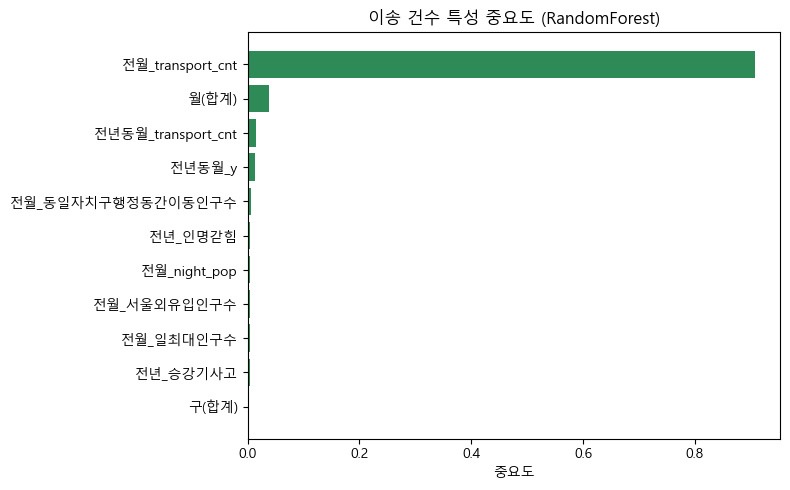

In [8]:
imp = pd.Series(bundles['RandomForest']['model'].feature_importances_, index=X_train.columns)
for prefix in ['구_', '월_']:
    cols = [c for c in imp.index if c.startswith(prefix)]
    imp[prefix.rstrip('_') + '(합계)'] = imp[cols].sum()
    imp = imp.drop(cols)
imp = imp.sort_values()
print(imp.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color='seagreen')
plt.xlabel('중요도')
plt.title('이송 건수 특성 중요도 (RandomForest)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_importance.png')
plt.show()

## A-7. 최종 모델 저장 · 구별 미래 예측
- 최종 모델 : 최고 모델을 학습 + 평가 데이터 전체로 다시 학습
- 저장 후 다시 불러와서 예측 : 저장 파일이 제대로 동작하는지 확인
- 입력 : 전처리의 `transport_future.csv` (첫 달만 실제 전월 값, 이후는 재귀 예측으로 채움)
- 결과 csv : `transport_forecast_by_gu.csv` (예측월 · 지역구명 · 예측_이송건수)
- 주의 : 먼 달일수록 예측 위에 예측을 쌓으므로 오차가 커질 수 있음

In [9]:
final = fit_model(best_name, make_X(data), data[target], 'transport')
save_bundle(final, 'transport')

loaded = load_bundle('transport')
check = np.allclose(predict(final, make_X(data.head())), predict(loaded, make_X(data.head())))
print('저장 모델 불러오기 확인 :', check)

fc = predict_months(loaded, future)
forecast = pd.DataFrame({
    '예측월': fc['ds'].dt.strftime('%Y-%m'),
    '지역구명': fc['District'],
    '예측_이송건수': fc['예측'].round(0).astype(int),
    '사용모델': best_name,
})
forecast.to_csv(RESULT_DIR / 'transport_forecast_by_gu.csv', index=False, encoding='utf-8-sig')

missing_gu = sorted(set(GU_LIST) - set(forecast['지역구명']))
if missing_gu:
    print('[주의] 입력 값이 부족해 예측하지 못한 구 :', missing_gu)
print(forecast.pivot(index='지역구명', columns='예측월', values='예측_이송건수'))

저장 모델 불러오기 확인 : True
예측월   2026-01  2026-02  2026-03  2026-04  2026-05  2026-06
지역구명                                                      
강남구      1279     1150     1234     1272     1340     1357
강동구      1146     1007     1084     1126     1216     1219
강북구      1046      949      996     1018     1103     1112
강서구      1222     1053     1101     1113     1179     1160
관악구      1082      978     1043     1079     1181     1204
광진구       790      705      749      761      838      853
구로구      1213     1045     1106     1108     1167     1137
금천구       608      554      575      594      626      623
노원구      1182      999     1055     1072     1143     1138
도봉구       798      698      697      682      709      724
동대문구     1015      920      973      972     1039     1045
동작구       731      664      683      684      728      731
마포구      1134     1025     1090     1125     1206     1210
서대문구      823      671      682      679      727      749
서초구      1083      978     1038    

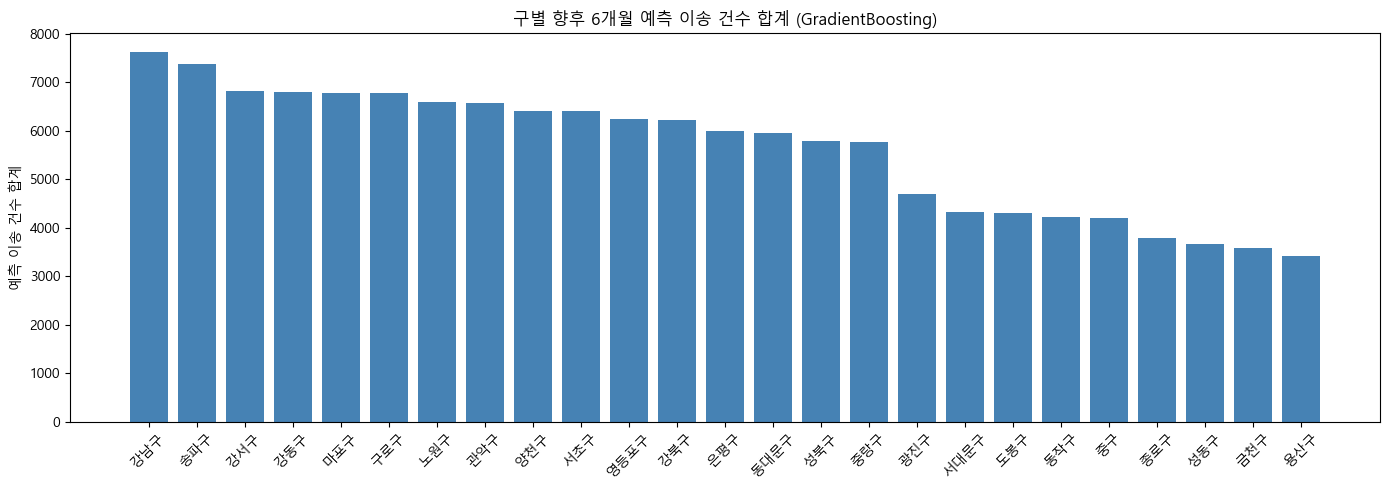

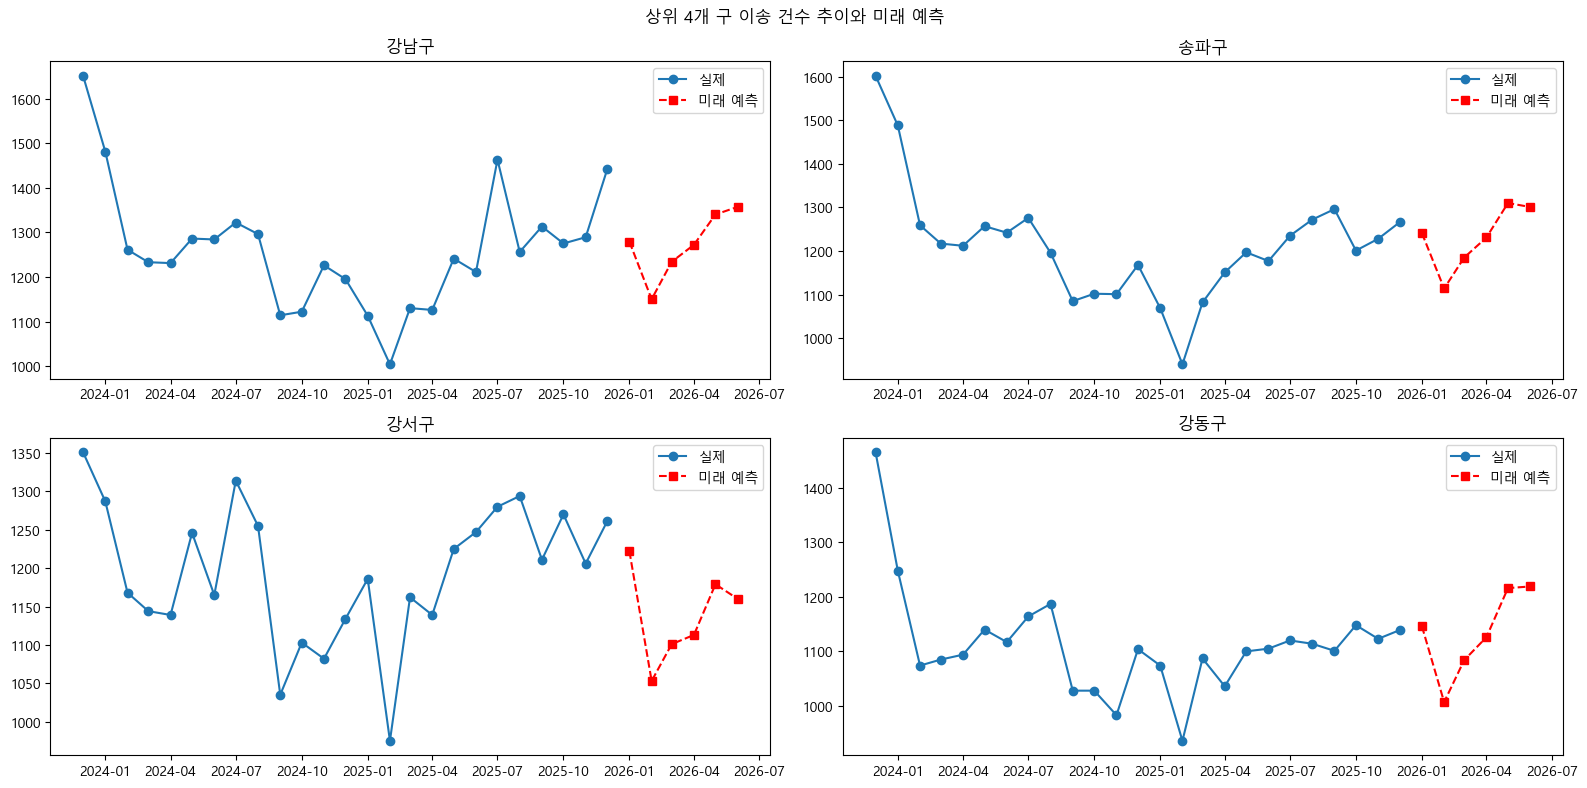

In [10]:
gu_total = forecast.groupby('지역구명')['예측_이송건수'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(gu_total.index, gu_total.values, color='steelblue')
plt.xticks(rotation=45)
plt.ylabel('예측 이송 건수 합계')
plt.title(f'구별 향후 {forecast["예측월"].nunique()}개월 예측 이송 건수 합계 ({best_name})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_forecast_by_gu.png')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, gu in zip(axes.flatten(), gu_total.index[:4]):
    real = full[(full['District'] == gu) & (full['ds'] >= full['ds'].max() - pd.DateOffset(months=24))]
    fut = forecast[forecast['지역구명'] == gu]
    ax.plot(real['ds'], real[target], marker='o', label='실제')
    ax.plot(pd.to_datetime(fut['예측월']), fut['예측_이송건수'], 'r--', marker='s', label='미래 예측')
    ax.set_title(gu)
    ax.legend()
plt.suptitle('상위 4개 구 이송 건수 추이와 미래 예측')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_forecast_top4.png')
plt.show()

---
# B. 인구 밀집 예측 (자치구 × 일)

## B-1. 데이터 불러오기 · 날짜 특성 추가
- 정답 : `일최대인구수`
- 숫자 특성 : 전처리에서 `선택`된 컬럼 (전일 인구, 7일 전 같은 요일 값 등)
- 요일 : 0(월) ~ 6(일), 평일·주말 인구 차이 반영
- 월 : 계절에 따른 차이 반영
- 주말여부 : 토·일이면 1
- 원-핫 인코딩 : 자치구 이름 → 0/1 컬럼

In [11]:
TARGET_POP = '일최대인구수'

pop = pd.read_csv(ML_DATA_DIR / 'population_selected.csv', encoding='utf-8-sig', parse_dates=['ds'])
pop_info = pd.read_csv(ML_DATA_DIR / 'features_population.csv', encoding='utf-8-sig')
pop = pop.sort_values(['District', 'ds']).reset_index(drop=True)

pop['요일'] = pop['ds'].dt.dayofweek
pop['월'] = pop['ds'].dt.month
pop['주말여부'] = (pop['요일'] >= 5).astype(int)

pop_features = pop_info.loc[pop_info['결과'] == '선택', '컬럼'].tolist() + ['요일', '월', '주말여부']

X_pop = pd.get_dummies(pop[pop_features + ['District']], columns=['District'], dtype=int)
y_pop = pop[TARGET_POP]
print('특성 :', pop_features)
print(X_pop.shape, '/', pop['ds'].min().date(), '~', pop['ds'].max().date())

특성 : ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff', '요일', '월', '주말여부']
(75825, 33) / 2018-04-12 ~ 2026-07-31


## B-2. 자치구별 요일 효과 확인
- 전체 상관이 약했던 이유 : 구마다 인구 규모 차이가 커서 요일 효과가 가려짐
- 해결 : 구별 평균으로 나눈 비율 (1보다 크면 평균보다 많음)
- `pivot_table` : 행 = 자치구, 열 = 요일, 값 = 평균 인구
- 해석 : 업무지구는 주말 감소, 주거지역은 변화 적음

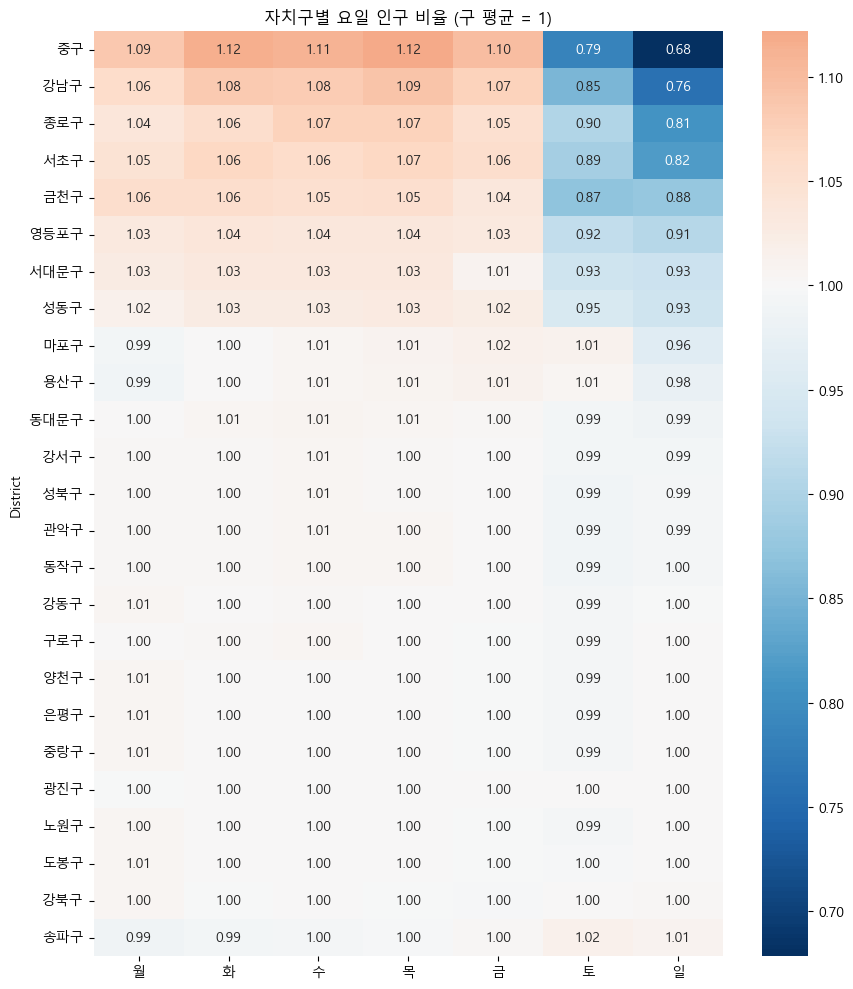

주말 인구 변화율(%)
District
중구     -26.7
강남구    -19.4
서초구    -14.6
종로구    -14.4
금천구    -12.6
영등포구    -8.6
서대문구    -6.8
성동구     -5.9
마포구     -1.3
동대문구    -1.2
용산구     -1.0
강서구     -0.9
관악구     -0.9
동작구     -0.8
성북구     -0.8
강동구     -0.5
구로구     -0.4
양천구     -0.3
은평구     -0.3
노원구     -0.3
중랑구     -0.2
도봉구     -0.1
광진구     -0.0
강북구      0.1
송파구      1.5


In [12]:
day_ratio = pop.pivot_table(index='District', columns='요일', values=TARGET_POP, aggfunc='mean')
day_ratio = day_ratio.div(day_ratio.mean(axis=1), axis=0)
day_ratio.columns = ['월', '화', '수', '목', '금', '토', '일']
day_ratio = day_ratio.sort_values('일')

plt.figure(figsize=(9, 10))
sns.heatmap(day_ratio, annot=True, fmt='.2f', cmap='RdBu_r', center=1)
plt.title('자치구별 요일 인구 비율 (구 평균 = 1)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_weekday_by_gu.png')
plt.show()

weekend_ratio = (day_ratio[['토', '일']].mean(axis=1) - 1) * 100
print('주말 인구 변화율(%)')
print(weekend_ratio.sort_values().round(1).to_string())

## B-3. 시간순 분할 · 모델 6종 학습
- 평가 기간 : 마지막 1년
- 학습 방식 : A와 같은 `fit_model` (주제별 설정만 다름)
- 데이터가 많아서(약 7만 행) 학습에 몇 분 걸릴 수 있음

In [13]:
split_date = pop['ds'].max() - pd.DateOffset(years=1) + pd.Timedelta(days=1)
train_mask = pop['ds'] < split_date
test_mask = pop['ds'] >= split_date

Xp_train, Xp_test = X_pop[train_mask], X_pop[test_mask]
yp_train, yp_test = y_pop[train_mask], y_pop[test_mask]
print(f'학습 : {Xp_train.shape} / 평가 : {Xp_test.shape} (평가 시작 {split_date.date()})')

pop_scores = []
pop_bundles = {}
pop_preds = {}
for name in MODEL_NAMES:
    bundle = fit_model(name, Xp_train, yp_train, 'population')
    pop_bundles[name] = bundle
    pop_preds[name] = predict(bundle, Xp_test)
    pop_scores.append({'모델': name, **evaluate(yp_test, pop_preds[name])})
    print(f'{name:18s} 완료')

# 기준선 : 7일 전 같은 요일 값 그대로
if '7일전_일최대인구수' in pop.columns:
    pop_scores.append({'모델': '기준선(7일 전 그대로)',
                       **evaluate(yp_test, pop.loc[test_mask, '7일전_일최대인구수'])})

pop_score_df = pd.DataFrame(pop_scores).sort_values('정확도(%)', ascending=False).reset_index(drop=True)
pop_score_df.to_csv(RESULT_DIR / 'population_model_scores.csv', index=False, encoding='utf-8-sig')
print(pop_score_df.round(3).to_string(index=False))

pop_best = pop_score_df[pop_score_df['모델'].isin(MODEL_NAMES)].iloc[0]['모델']
pop_best_pred = pop_preds[pop_best]
print('\n최고 모델 :', pop_best)

학습 : (66700, 33) / 평가 : (9125, 33) (평가 시작 2025-08-01)
LinearRegression   완료
Ridge              완료
DecisionTree       완료
RandomForest       완료
GradientBoosting   완료
DNN                완료
              모델  정확도(%)    R2       MAE      RMSE
    RandomForest  98.175 0.986  8723.367 20822.038
GradientBoosting  97.992 0.986  9361.539 20994.811
   기준선(7일 전 그대로)  97.545 0.952 12015.489 38631.152
    DecisionTree  97.532 0.977 11350.535 26822.558
           Ridge  97.136 0.969 13959.365 30773.080
LinearRegression  97.131 0.969 13967.067 30764.459
             DNN  95.021 0.965 20855.926 32767.760

최고 모델 : RandomForest


## B-4. 시각화 ① 모델 비교 · DNN 학습 곡선

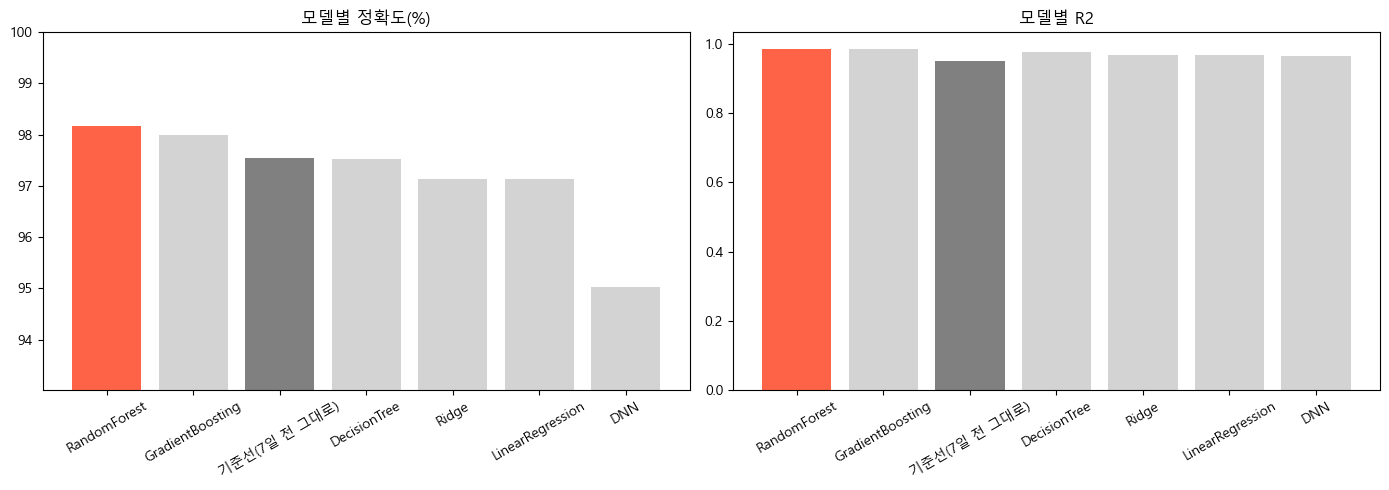

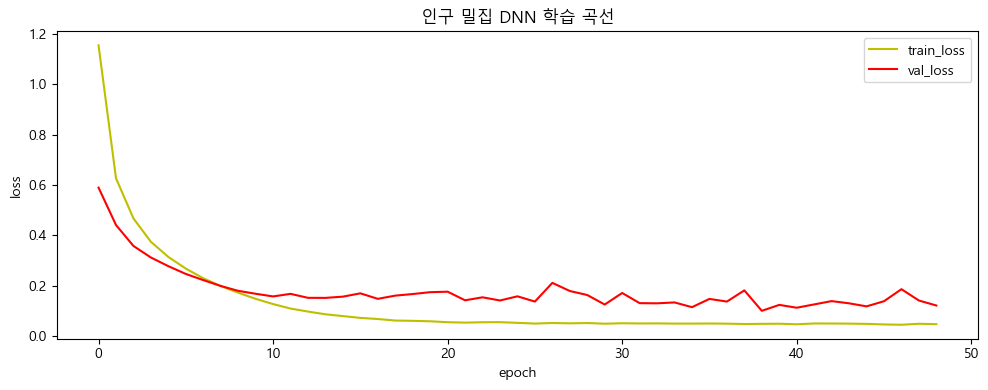

In [14]:
colors = ['gray' if m.startswith('기준선') else ('tomato' if m == pop_best else 'lightgray')
          for m in pop_score_df['모델']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(pop_score_df['모델'], pop_score_df['정확도(%)'], color=colors)
axes[0].set_title('모델별 정확도(%)')
axes[0].set_ylim(pop_score_df['정확도(%)'].min() - 2, 100)
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(pop_score_df['모델'], pop_score_df['R2'], color=colors)
axes[1].set_title('모델별 R2')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_model_scores.png')
plt.show()

plot_history(pop_bundles['DNN']['history'], '인구 밀집 DNN 학습 곡선', RESULT_DIR / 'population_dnn_history.png')

## B-5. 시각화 ② 평가 기간 결과
- 산점도 : 대각선에 가까울수록 정확
- 상위 4개 구 추이 : 주기적 오르내림 = 평일·주말 차이
- 요일별 평균 : 모델이 평일·주말 차이를 잘 잡았는지 확인
- 결과 csv : `population_test_predictions.csv` (지역구명 포함)

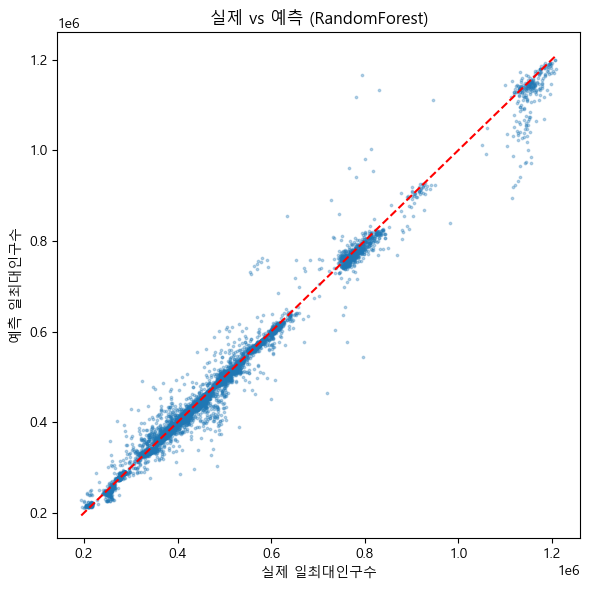

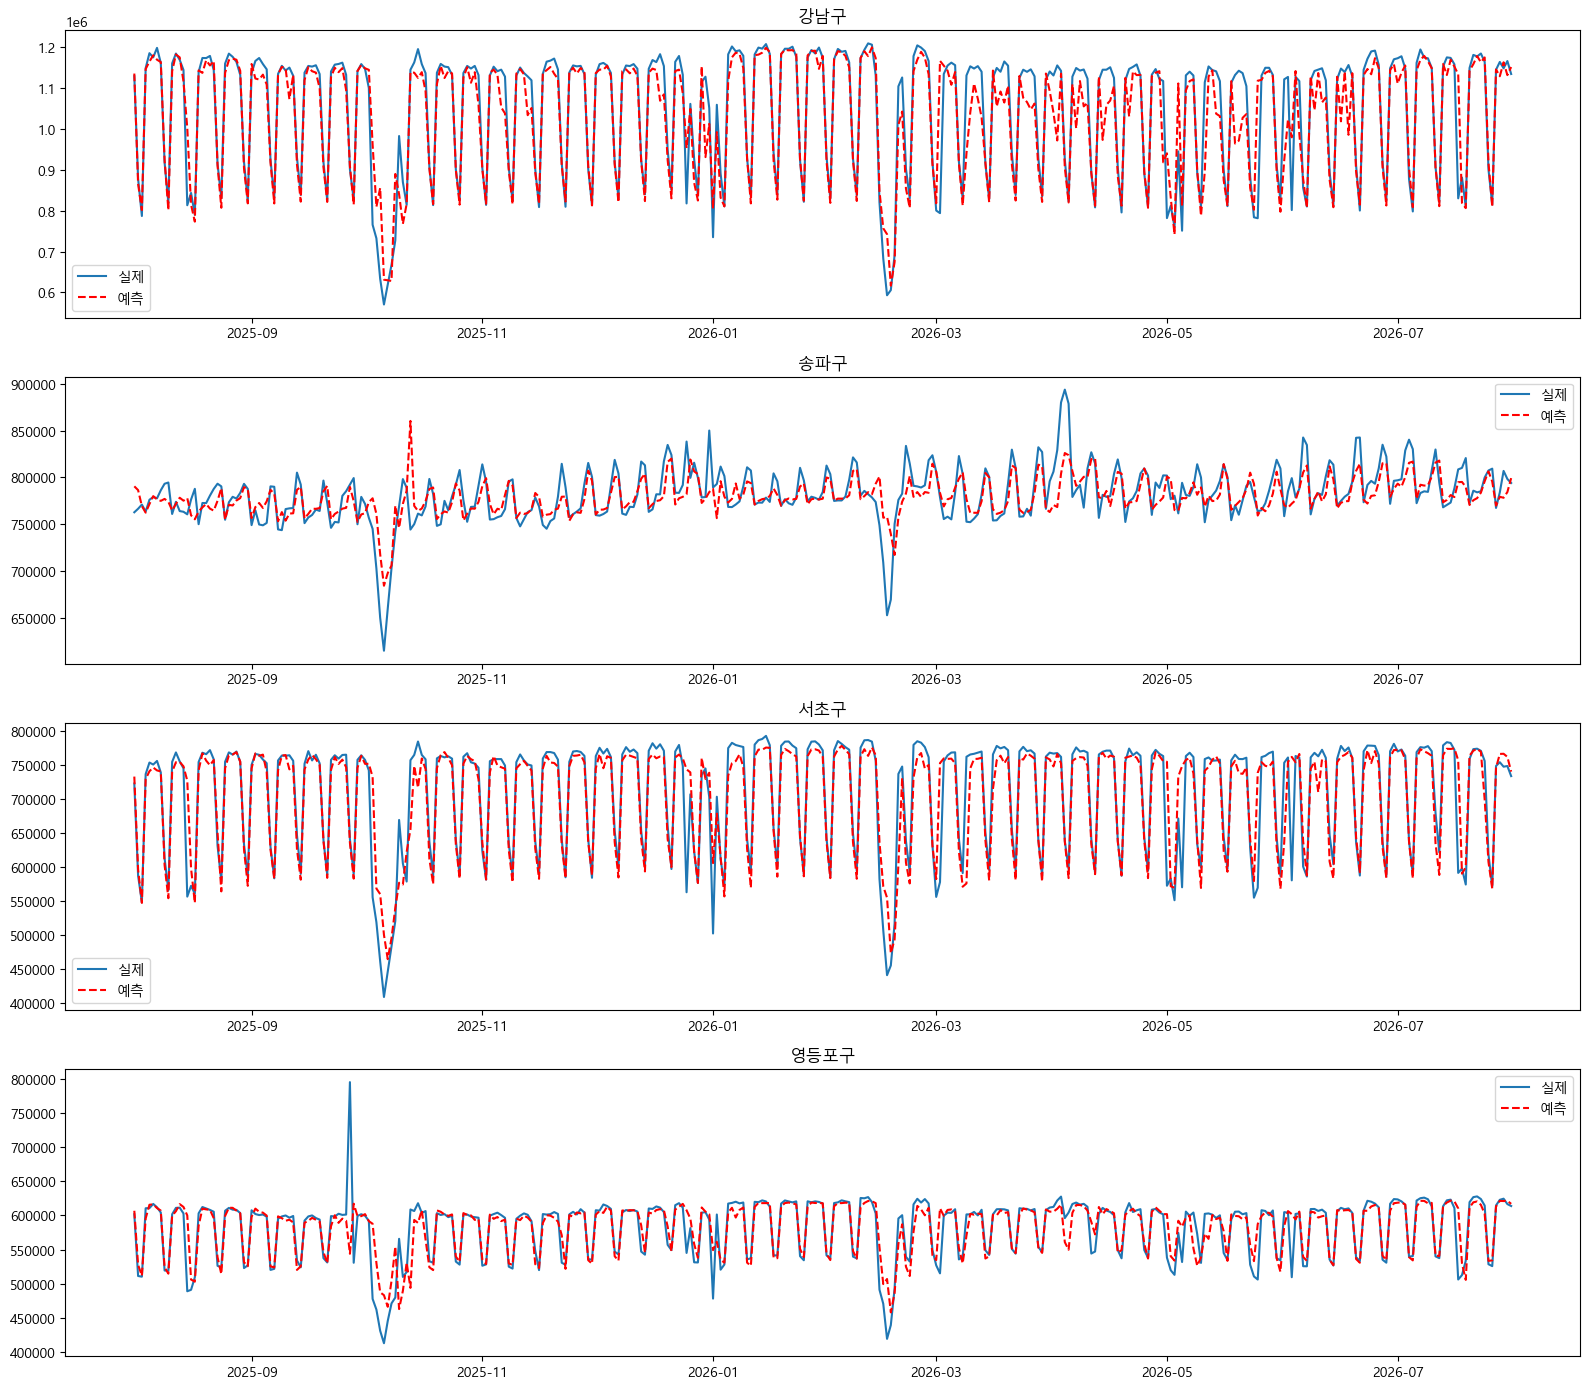

In [15]:
pop_result = pd.DataFrame({
    '날짜': pop.loc[test_mask, 'ds'].dt.strftime('%Y-%m-%d').values,
    '지역구명': pop.loc[test_mask, 'District'].values,
    '실제_일최대인구수': yp_test.values.round(0),
    '예측_일최대인구수': pop_best_pred.round(0),
})
pop_result['오차율(%)'] = ((pop_result['예측_일최대인구수'] - pop_result['실제_일최대인구수']).abs()
                         / pop_result['실제_일최대인구수'] * 100).round(2)
pop_result.to_csv(RESULT_DIR / 'population_test_predictions.csv', index=False, encoding='utf-8-sig')

plt.figure(figsize=(6, 6))
plt.scatter(yp_test, pop_best_pred, s=3, alpha=0.3)
lim = [yp_test.min(), yp_test.max()]
plt.plot(lim, lim, 'r--')
plt.xlabel('실제 일최대인구수')
plt.ylabel('예측 일최대인구수')
plt.title(f'실제 vs 예측 ({pop_best})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_scatter.png')
plt.show()

top4 = pop_result.groupby('지역구명')['실제_일최대인구수'].mean().sort_values(ascending=False).head(4).index
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, gu in zip(axes, top4):
    part = pop_result[pop_result['지역구명'] == gu]
    ax.plot(pd.to_datetime(part['날짜']), part['실제_일최대인구수'], label='실제')
    ax.plot(pd.to_datetime(part['날짜']), part['예측_일최대인구수'], 'r--', label='예측')
    ax.set_title(gu)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_trend.png')
plt.show()

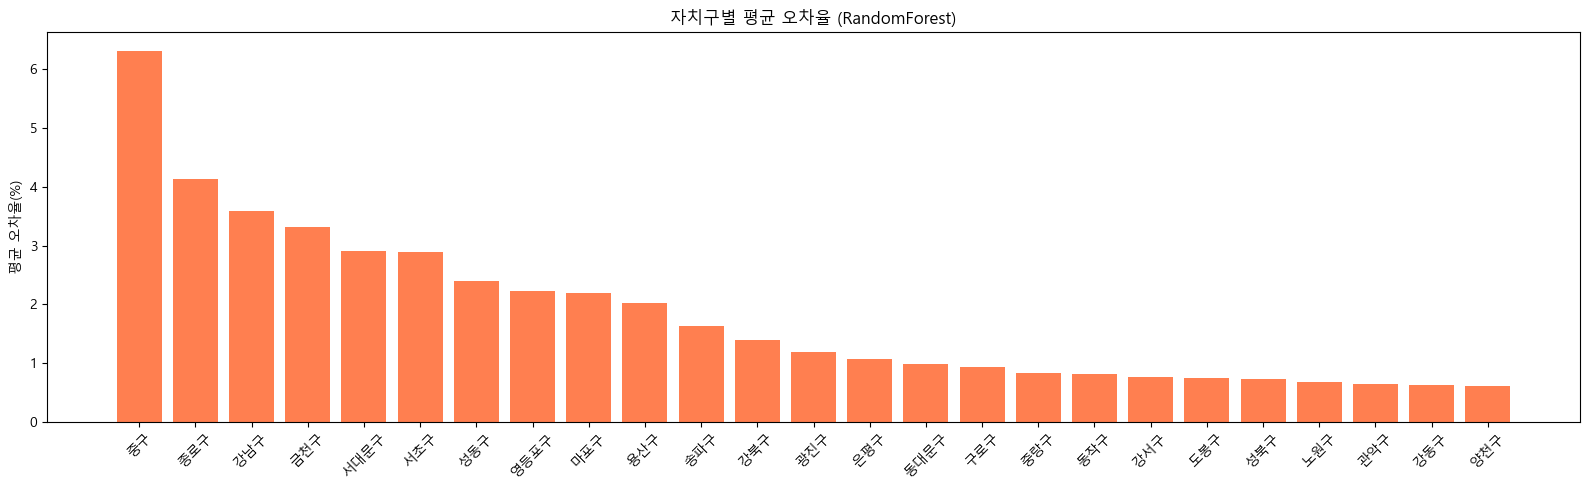

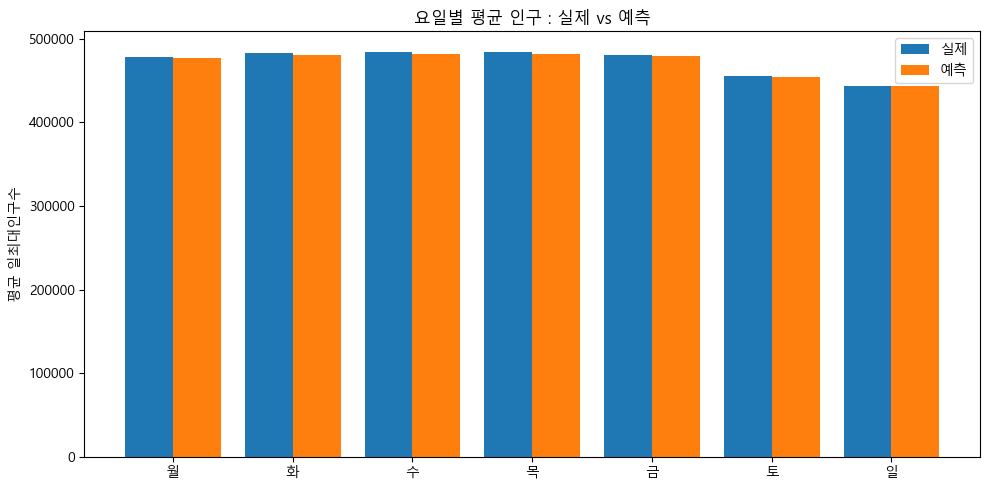

In [16]:
gu_err = pop_result.groupby('지역구명')['오차율(%)'].mean().sort_values(ascending=False)
plt.figure(figsize=(16, 5))
plt.bar(gu_err.index, gu_err.values, color='coral')
plt.xticks(rotation=45)
plt.ylabel('평균 오차율(%)')
plt.title(f'자치구별 평균 오차율 ({pop_best})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_district_error.png')
plt.show()

pop_result['요일'] = pd.to_datetime(pop_result['날짜']).dt.dayofweek
day_mean = pop_result.groupby('요일')[['실제_일최대인구수', '예측_일최대인구수']].mean()
x = np.arange(7)
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, day_mean['실제_일최대인구수'], width=0.4, label='실제')
plt.bar(x + 0.2, day_mean['예측_일최대인구수'], width=0.4, label='예측')
plt.xticks(x, ['월', '화', '수', '목', '금', '토', '일'])
plt.ylabel('평균 일최대인구수')
plt.title('요일별 평균 인구 : 실제 vs 예측')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_weekday.png')
plt.show()

## B-6. 특성 중요도 · 최종 모델 저장
- 중요도 : A-6과 같은 방식, `District_` 원-핫 합산
- 최종 모델 : 전체 기간으로 다시 학습 후 저장, 다시 불러와 동작 확인

7일전_일최대인구수           0.960
전일_night_pop         0.014
전일_pop_diff          0.011
전일_일최대이동인구수          0.004
District(합계)         0.003
전일_동일자치구행정동간이동인구수    0.003
요일                   0.003
주말여부                 0.002
월                    0.001
dtype: float64


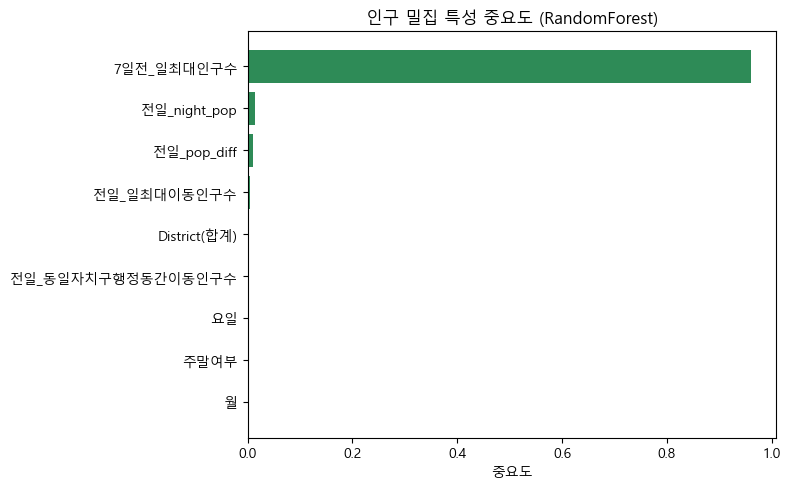

저장 모델 불러오기 확인 : True


In [17]:
imp = pd.Series(pop_bundles['RandomForest']['model'].feature_importances_, index=X_pop.columns)
gu_cols = [c for c in imp.index if c.startswith('District_')]
imp['District(합계)'] = imp[gu_cols].sum()
imp = imp.drop(gu_cols).sort_values()
print(imp.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color='seagreen')
plt.xlabel('중요도')
plt.title('인구 밀집 특성 중요도 (RandomForest)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_importance.png')
plt.show()

pop_final = fit_model(pop_best, X_pop, y_pop, 'population')
save_bundle(pop_final, 'population')
pop_loaded = load_bundle('population')
print('저장 모델 불러오기 확인 :',
      np.allclose(predict(pop_final, X_pop.head()), predict(pop_loaded, X_pop.head())))

---
## 결과 요약

In [18]:
print('[이송 건수] 최고 모델 :', best_name)
print(score_df.round(2).to_string(index=False))
print('\n[인구 밀집] 최고 모델 :', pop_best)
print(pop_score_df.round(2).to_string(index=False))

print('\n[결과 파일] ->', RESULT_DIR)
for f in ['transport_model_scores.csv', 'transport_test_predictions.csv', 'transport_forecast_by_gu.csv',
          'population_model_scores.csv', 'population_test_predictions.csv']:
    print('  ', f)

[이송 건수] 최고 모델 : GradientBoosting
              모델  6개월_정확도(%)  6개월_MAE  1개월_정확도(%)  1개월_R2
GradientBoosting       94.04    57.21       95.03    0.93
           Ridge       93.89    57.52       94.73    0.93
LinearRegression       93.88    57.67       94.72    0.93
    RandomForest       93.57    61.06       95.33    0.94
   기준선(마지막 달 유지)       93.25    66.35       95.41    0.93
      기준선(전년 동월)       90.68    90.85       90.68    0.78
    DecisionTree       90.11    94.07       94.38    0.92
             DNN       88.40   105.12       93.99    0.90

[인구 밀집] 최고 모델 : RandomForest
              모델  정확도(%)   R2      MAE     RMSE
    RandomForest   98.17 0.99  8723.37 20822.04
GradientBoosting   97.99 0.99  9361.54 20994.81
   기준선(7일 전 그대로)   97.54 0.95 12015.49 38631.15
    DecisionTree   97.53 0.98 11350.53 26822.56
           Ridge   97.14 0.97 13959.36 30773.08
LinearRegression   97.13 0.97 13967.07 30764.46
             DNN   95.02 0.97 20855.93 32767.76

[결과 파일] -> C:\ai\source\09_Pro

## 참고

- 관할 변경 4개 구(성동·광진·금천·구로) : 사용 구간이 짧아 다른 구보다 학습 행이 적음
- 인구 밀집 : 공휴일 정보가 없어 명절 연휴처럼 급감하는 날은 예측이 늦게 따라감 → 공휴일 여부 컬럼 추가 시 개선 여지